# Вычислительный практикум

## Практическое занятие \#2.1. Итерполяция

### Основные сведения

#### Постановка задачи интерполяции

Пусть $a<b$, функция $f:[a,b]\to\mathbb{R}$ задана в $l$ попарно различных узлах

$$
a\le x_1<x_2<\dots<x_l\le b,
$$

а известные значения имеют вид $y_i=f(x_i)$, $i=1,\dots,l$. Требуется построить полином $P_{l-1}$ степени не выше $l-1$, для которого

$$
P_{l-1}(x_i)=y_i=f(x_i),\qquad i=1,\dots,l.
$$

Такой полином называют интерполяционным. Для самого факта его существования достаточно, чтобы значения $y_i$ были заданы, а узлы были попарно различными. При исследовании погрешности дополнительно будем считать, что $f\in C^l([a,b])$, то есть функция имеет непрерывные производные до порядка $l$ включительно.

Интерполяция требует точного совпадения в узлах. Приближение понимается шире: приближающая функция должна быть близка к данным по выбранному критерию, но не обязана проходить через каждую точку. Линейная регрессия является одним из методов такого приближения.


#### Интерполяционный полином Лагранжа

Полином Лагранжа записывается в виде

$$
P_{l-1}(x)=\sum_{j=1}^{l}y_jL_j(x),
$$

где

$$
L_j(x)=\prod_{\substack{m=1\\m\ne j}}^{l}\frac{x-x_m}{x_j-x_m}.
$$

Базисные полиномы удовлетворяют условиям

$$
L_j(x_i)=
\begin{cases}
1,&i=j,\\
0,&i\ne j.
\end{cases}
$$

Поэтому при подстановке $x=x_i$ в сумме остается только одно слагаемое и выполняется равенство $P_{l-1}(x_i)=y_i$.

#### Интерполяционный полином Ньютона

Тот же интерполяционный полином можно представить в форме Ньютона:

$$
\begin{aligned}
P_{l-1}(x)={}&f[x_1]+f[x_1,x_2](x-x_1)+\dots\\
&+f[x_1,x_2,\dots,x_l](x-x_1)(x-x_2)\cdots(x-x_{l-1}).
\end{aligned}
$$

Разделенные разности задаются рекурсивно:

$$
f[x_i]=f(x_i),
$$

$$
f[x_i,x_{i+1}]=\frac{f(x_{i+1})-f(x_i)}{x_{i+1}-x_i},
$$

$$
f[x_i,\dots,x_{i+k}]
=\frac{f[x_{i+1},\dots,x_{i+k}]-f[x_i,\dots,x_{i+k-1}]}{x_{i+k}-x_i}.
$$

Формы Лагранжа и Ньютона отличаются способом записи и вычисления коэффициентов, но задают один и тот же интерполяционный полином.


#### Теорема о существовании и единственности интерполяционного полинома

**Теорема.** Для $l$ попарно различных узлов $x_1,\dots,x_l$ и произвольных значений $y_1,\dots,y_l$ существует единственный полином степени не выше $l-1$, удовлетворяющий условиям

$$
P_{l-1}(x_i)=y_i,\qquad i=1,\dots,l.
$$

**Доказательство.** Существование следует из явной формулы Лагранжа. Полином

$$
P_{l-1}(x)=\sum_{j=1}^{l}y_jL_j(x)
$$

имеет степень не выше $l-1$ и в каждом узле $x_i$ принимает значение $y_i$.

Докажем единственность. Предположим, что существуют два таких полинома $P_{l-1}$ и $Q_{l-1}$. Рассмотрим их разность

$$
R(x)=P_{l-1}(x)-Q_{l-1}(x).
$$

Степень $R$ не выше $l-1$, причем $R(x_i)=0$ для всех $i=1,\dots,l$. Следовательно, $R$ имеет $l$ различных корней. Ненулевой полином степени не выше $l-1$ не может иметь более $l-1$ различных корней, поэтому $R\equiv0$. Значит, $P_{l-1}\equiv Q_{l-1}$. Теорема доказана.

#### Погрешность интерполяции

Если $f\in C^l([a,b])$, то для каждого $x\in[a,b]$ существует точка $\xi$, лежащая между наименьшим и наибольшим из чисел $x,x_1,\dots,x_l$, такая что

$$
R_T(x)=f(x)-P_{l-1}(x)=\frac{f^{(l)}(\xi)}{l!}\prod_{i=1}^{l}(x-x_i).
$$

Формула показывает, что погрешность зависит не только от гладкости функции, но и от количества и расположения узлов.

#### Другой пример аппроксимации. Линейное приближение методом наименьших квадратов

Для наблюдений $(x_i,y_i)$ линейная модель имеет вид

$$
\widehat y_i=\beta_0+\beta_1x_i.
$$

Коэффициенты $\beta_0$ и $\beta_1$ выбираются так, чтобы минимизировать сумму квадратов остатков:

$$
S(\beta_0,\beta_1)=\sum_{i=1}^{n}\left(y_i-\beta_0-\beta_1x_i\right)^2.
$$

В отличие от интерполяции, линия регрессии обычно не проходит через все исходные точки. Она отражает общую линейную зависимость между признаками.

## Задания

1. Для заданных попарно различных узлов $x_i$ и значений $y_i=f(x_i)$ построить интерполяционный полином в форме Лагранжа и Ньютона.
3. Написать на Python функцию, которая по входным массивам $x_i$ и $y_i$ строит интерполяционный полином. Проверить выполнение условий $P_{l-1}(x_i)=y_i$ и построить график.
2. Представить полученный полином в явном виде, то есть выписать его коэффициенты по степеням $x$. Если используется библиотека `sympy`, то в качестве решения данного пункта можно представить построенную символьную функцию $P_{l-1}(x)$.
5. Провести вычислительный эксперимент для функции $f(x)=\sin x$ на отрезке $[-\pi,\pi]$: сформировать таблицу узлов, построить полином и сравнить графики $f(x)$ и $P_{l-1}(x)$ на исходном и расширенном интервалах.
6. Рассмотреть функцию Рунге

    $$
    f(x)=\frac{1}{1+25x^2},\qquad x\in[-1,1].
    $$

   Построить интерполяционные полиномы для нескольких наборов равноотстоящих узлов и сравнить их с исходной функцией по графику и таблице значений.
7. Подготовить отчет о выполнении работы. Отчет должен содержать:
   - постановку задачи;
   - краткое описание используемых методов;
   - описание входных данных и ожидаемых результатов;
   - программную реализацию и результаты вычислений;
   - интерпретацию полученных результатов и выводы.

Для экспериментов рекомендуется привести таблицу **«Сравнение значений исходной функции и интерполяционного полинома»** со столбцами $x_i$, $f(x_i)$, $P^{L}_{l-1}(x_i)$, $P^{N}_{l-1}(x_i)$, $R_T^L(x_i)$, $R_T^N(x_i)$, $|f(x_i)-P^{L}_{l-1}(x_i)|$ и $|f(x_i)-P^{N}_{l-1}(x_i)|$.


## Литература

1. Лебедева А. В., Пакулина А. Н. *Практикум по методам вычислений*. СПб.: Санкт-Петербургский государственный университет, 2021. 156 с.
3. Мысовских И. П. *Лекции по методам вычислений*. М.: Физматгиз, 1962. 342 с.
1. Амосов А. А., Дубинский Ю. А., Копченова Н. В. *Вычислительные методы*. М.: Лань, 2025. 672 с.
2. Бахвалов Н. С., Жидков Н. П., Кобельков Г. М. *Численные методы*. М.: БИНОМ. Лаборатория знаний, 2003. 632 с.

## Примеры программной реализации и результаты

Ниже приведены примеры реализации интерполяции полиномом Лагранжа и линейного приближения методом наименьших квадратов.

### Пример 1. Интерполяция функции $f(x)=\sin x$


In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
def lagrange_poly(x_vals, y_vals):
    x_vals = np.asarray(x_vals)
    y_vals = np.asarray(y_vals)

    polynomial = np.poly1d([0.0])

    for j, x_j in enumerate(x_vals):
        numerator = np.poly1d([1.0])
        denominator = 1.0

        for m, x_m in enumerate(x_vals):
            if m == j:
                continue
            numerator = np.polymul(numerator, np.poly1d([1.0, -x_m]))
            denominator *= x_j - x_m

        basis_polynomial = numerator / denominator
        polynomial = polynomial + y_vals[j] * basis_polynomial

    return np.round(polynomial.coeffs, decimals=12)

Подготовим узлы интерполяции и соответствующие значения функции.


In [3]:
h = 0.5
x = np.arange(-np.pi, np.pi + h, h)
y = np.sin(x)

table = np.column_stack((x, y))
print("   x  \t\t  sin(x)")
print(table)

   x  		  sin(x)
[[-3.14159265e+00 -1.22464680e-16]
 [-2.64159265e+00 -4.79425539e-01]
 [-2.14159265e+00 -8.41470985e-01]
 [-1.64159265e+00 -9.97494987e-01]
 [-1.14159265e+00 -9.09297427e-01]
 [-6.41592654e-01 -5.98472144e-01]
 [-1.41592654e-01 -1.41120008e-01]
 [ 3.58407346e-01  3.50783228e-01]
 [ 8.58407346e-01  7.56802495e-01]
 [ 1.35840735e+00  9.77530118e-01]
 [ 1.85840735e+00  9.58924275e-01]
 [ 2.35840735e+00  7.05540326e-01]
 [ 2.85840735e+00  2.79415498e-01]
 [ 3.35840735e+00 -2.15119988e-01]]


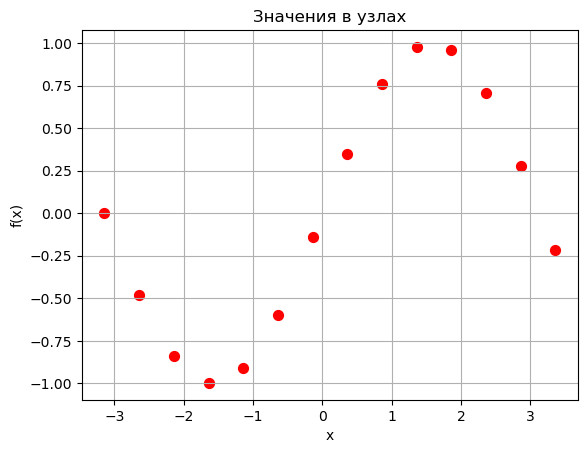

In [4]:
plt.scatter(x, y, color="red", s= 50)
plt.xlabel("x")
plt.ylabel("f(x)")
plt.title("Значения в узлах")
plt.grid(True)
plt.show()

In [5]:
coeffs = lagrange_poly(x, y)
print(coeffs)

[ 1.39000000e-10 -3.00000000e-12 -2.48180000e-08  7.10000000e-11
  2.75448000e-06 -5.20000000e-10 -1.98409319e-04  1.63400000e-09
  8.33332898e-03 -2.11800000e-09 -1.66666664e-01  9.01000000e-10
  1.00000000e+00 -5.50000000e-11]


In [6]:
# Полином в стандартной форме по убыванию степеней:
print(np.poly1d(coeffs))

          13         12             11           10             9
1.39e-10 x  - 3e-12 x  - 2.482e-08 x  + 7.1e-11 x  + 2.754e-06 x
            8             7             6            5             4
 - 5.2e-10 x - 0.0001984 x + 1.634e-09 x + 0.008333 x - 2.118e-09 x
           3            2
 - 0.1667 x + 9.01e-10 x + 1 x - 5.5e-11


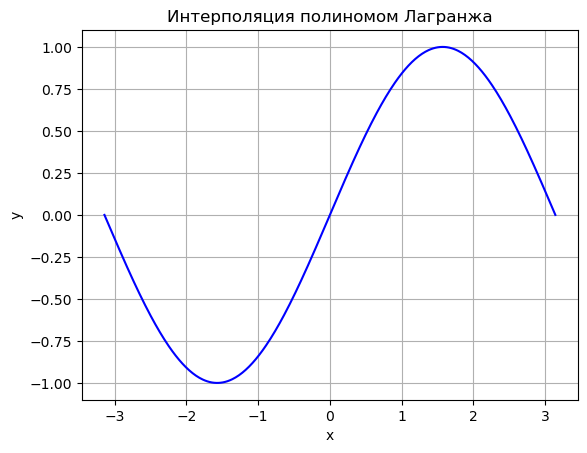

In [7]:
p = np.poly1d(coeffs)

xx = np.linspace(-np.pi, np.pi, 400)
yy = p(xx)

plt.plot(xx, yy, color="blue")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Интерполяция полиномом Лагранжа")
plt.grid(True)
plt.show()

Вычислим значение построенного полинома в выбранной точке.


In [8]:
arg = 3.53407346e-01
val = p(arg)
print(val)

0.34609657859353576


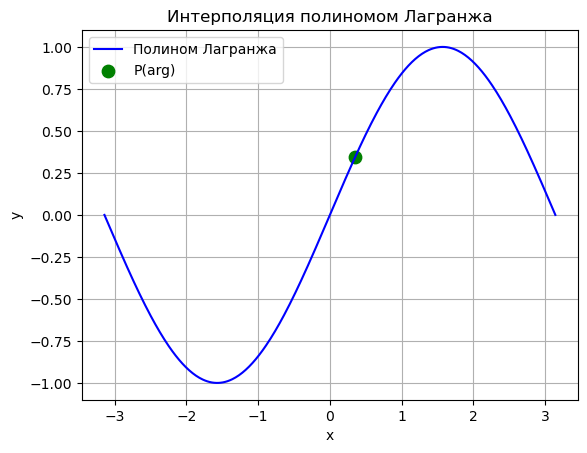

In [9]:
plt.plot(xx, yy, label="Полином Лагранжа", color="blue")
plt.scatter(arg, val, color="green", s=80, label="P(arg)")

plt.xlabel("x")
plt.ylabel("y")
plt.title("Интерполяция полиномом Лагранжа")
plt.grid(True)
plt.legend()
plt.show()

Сравним интерполяционный полином с исходной функцией на расширенном интервале.


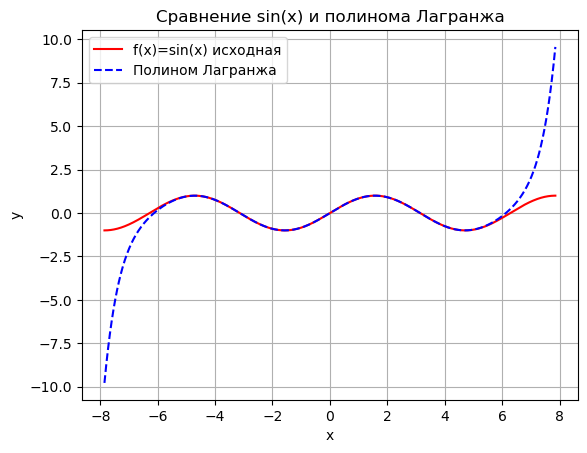

In [10]:
xx_new = np.linspace(-2.5*np.pi, 2.5*np.pi, 1000)
yy_sin = np.sin(xx_new)
yy_new = p(xx_new)

plt.plot(xx_new, yy_sin, label="f(x)=sin(x) исходная", color="red")
plt.plot(xx_new, yy_new, label="Полином Лагранжа", color="blue", linestyle="--")

plt.xlabel("x")
plt.ylabel("y")
plt.title("Сравнение sin(x) и полинома Лагранжа")
plt.grid(True)
plt.legend(loc="upper left")
plt.show()

На отрезке интерполяции полином проходит через все заданные узлы. За пределами этого отрезка выполняется уже экстраполяция, поэтому расхождение с исходной функцией может увеличиваться.

### Пример 2. Линейная регрессия для данных

В данном примере для иллюстрации используется файл `files/housing.csv`.

In [11]:
def read_input_file(filepath):
        data = np.genfromtxt(filepath, delimiter=",", dtype=None, encoding="utf-8", names=True)
        return data

In [12]:
file_name = "files/housing.csv"
data = read_input_file(file_name)
print("   №:   price: lotsize:")
print(data[:5]) # первые 5 строчек

   №:   price: lotsize:
[('"1"', 42000., 5850, 3, 1, 2, '"yes"', '"no"', '"yes"', '"no"', '"no"', 1, '"no"')
 ('"2"', 38500., 4000, 2, 1, 1, '"yes"', '"no"', '"no"', '"no"', '"no"', 0, '"no"')
 ('"3"', 49500., 3060, 3, 1, 1, '"yes"', '"no"', '"no"', '"no"', '"no"', 0, '"no"')
 ('"4"', 60500., 6650, 3, 1, 2, '"yes"', '"yes"', '"no"', '"no"', '"no"', 0, '"no"')
 ('"5"', 61000., 6360, 2, 1, 1, '"yes"', '"no"', '"no"', '"no"', '"no"', 0, '"no"')]


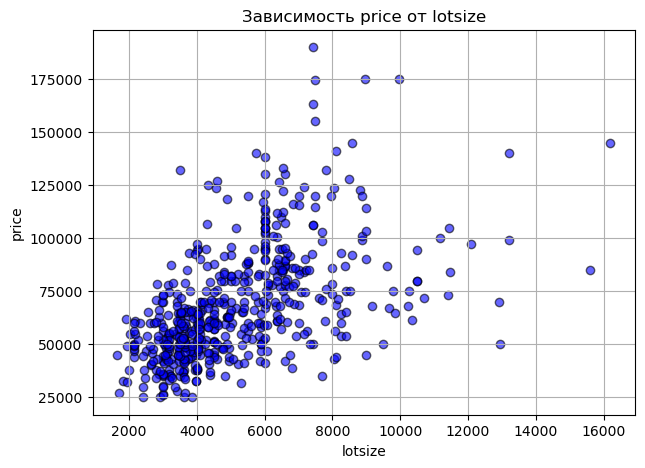

In [13]:
plt.figure(figsize=(7, 5))
plt.scatter(data["lotsize"], data["price"], c="blue", alpha=0.6, edgecolors="k", zorder = 1)

plt.xlabel("lotsize")
plt.ylabel("price")

plt.title("Зависимость price от lotsize")
plt.grid(True, zorder = -1)
plt.show()

In [14]:
X = data["lotsize"].reshape(-1, 1)
y = data["price"]

X_b = np.c_[np.ones((X.shape[0], 1)), X]  # shape: (m, 2)

theta = np.linalg.inv(X_b.T @ X_b) @ X_b.T @ y

theta0, theta1 = theta
print(f"Линейная модель: price = {theta0:.2f} + {theta1:.2f} * lotsize")

Линейная модель: price = 34136.19 + 6.60 * lotsize


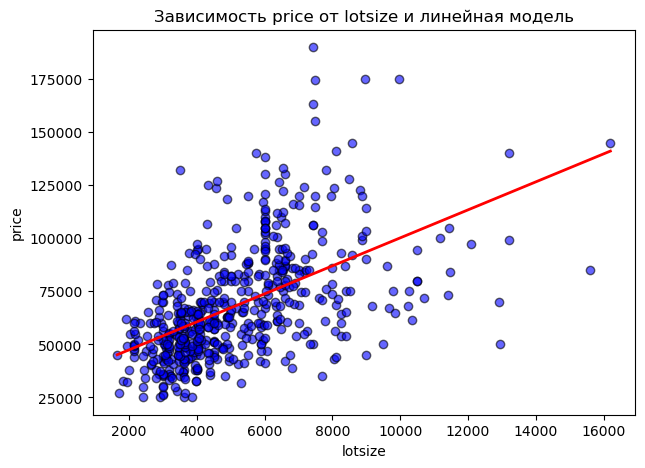

In [15]:
plt.figure(figsize=(7, 5))
plt.scatter(X, y, c="blue", alpha=0.6, edgecolors="k", zorder=3)

plt.xlabel("lotsize")
plt.ylabel("price")

plt.title("Зависимость price от lotsize и линейная модель")

x_line = np.linspace(X.min(), X.max(), 100).reshape(-1, 1)
x_line_b = np.c_[np.ones((x_line.shape[0], 1)), x_line]
y_line = x_line_b @ theta

plt.plot(x_line, y_line, "r-", linewidth=2, zorder=4)

Полученная модель имеет вид

$$
\widehat{price}=34136{.}19+6{.}60\cdot lotsize.
$$

Коэффициент при `lotsize` показывает среднее изменение прогнозируемой цены при увеличении площади участка на одну единицу в рамках рассматриваемых данных. Свободный член является параметром модели. Интерпретировать его как реальную цену объекта с нулевой площадью вне области наблюдений не следует.
